In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.collections import LineCollection
from collections import Counter
from scipy.optimize import curve_fit
from scipy.optimize import least_squares
from scipy.stats import ttest_1samp

plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams["font.family"] = "serif"

In [ ]:
dataF = np.load('dataF.npy')
dataN = np.load('dataN.npy')
dataO = np.load('dataO.npy')
dataS = np.load('dataS.npy')
dataZ = np.load('dataZ.npy')

folders = [dataF, dataN, dataO, dataS, dataZ]
filenames = ['F', 'N', 'O', 'S', 'Z']
setnames = ['A', 'B', 'C', 'D', 'E']

# Colormap and normalization
cmap = plt.cm.viridis
norm = plt.Normalize(0.5, 1.5)

data = dataF[0]

time = np.linspace(0, 23.6, len(dataF[0]))

scales = 9
epochs = np.logspace(
    np.log10(4),
    np.log10(4096/4),
    scales)

x_extrapolate = np.linspace(4, 4096/4, 100)

print(epochs)

[   4.    8.   16.   32.   64.  128.  256.  512. 1024.]


In [3]:
def prepros(tseries):
    mean = np.mean(tseries)
    mean_centered = tseries - mean
    prepros = np.cumsum(mean_centered)
    return prepros

def linear(x, m, b):
    return m*x + b

def gaussian(x, amplitude, mean, sigma):
    return amplitude * np.exp(-((x - mean) ** 2) / (2 * sigma ** 2))

def sigmoid(x, L, x0, k, b):
    z = k * (x - x0)
    z = np.clip(z, -60, 60)  # prevent overflow
    return L / (1 + np.exp(-z)) + b

def fitting_sig(x, y, p0=None):
    # default starting guess
    if p0 is None:
        L0 = np.max(y) - np.min(y)
        x0_0 = np.median(x)
        k0 = 1.0
        b0 = np.min(y)
        p0 = [L0, x0_0, k0, b0]

    # residuals
    def residuals(params, x_obs, y_obs):
        return sigmoid(x_obs, *params) - y_obs

    result = least_squares(
        residuals,
        p0,
        args=(x, y),
        method="trf",
        max_nfev=20000
    )

    return result.x

def fitting_lin(segment_x, segment_y):
    popt, pcov = curve_fit(linear, segment_x, segment_y)
    m, b = popt
    return m, b

def RMS_i(f1,f2,n):
    rms_i = np.sqrt( (1/n) * np.sum((f1 - f2)**2) )
    return rms_i

def RMS(residuals):
    F_n = np.sqrt( np.mean (np.array(residuals)**2) )
    return F_n

def DFA(prepros):
    RMS_lin_list = []
    # RMS_sig_list = []

    for i in epochs:
        boundaries = np.arange(0,4097,i).astype(int)
        residuals_lin = np.array([])
        # residuals_sig = np.array([])

        # Epoch processing
        for j in range(len(boundaries)-1):
            segment_x = [k for k in range(int(boundaries[j]), int(boundaries[j+1]))]
            segment_y = prepros[boundaries[j]:boundaries[j+1]]

            # Fitting
            m, b = fitting_lin(segment_x, segment_y)
            # L, x0, k, b = fitting_sig(segment_x, segment_y)

            # RMS Computation 
            residuals_lin = np.concatenate(( residuals_lin , np.array(segment_y) - np.array(linear(np.array(segment_x), m, b)) ))
            # np.concatenate(( residuals_sig , np.array(segment_y) - np.array(sigmoid(np.array(segment_x), L, x0, k, b)) ))

        RMS_lin = RMS( residuals_lin )
        RMS_lin_list.append(RMS_lin)
    

    return RMS_lin_list #, RMS_sig_list

In [4]:
# # DATA GENERATION
# for folder in range(len(folders)):
#     DFA_results = []                    # Array to hold DFA results for all files in a folder. list per file.
#     DFA_Hurst = []

#     for file in folders[folder]:
#         data = file
#         processed = prepros(data)
#         DFA_result_file = DFA(processed)
#         DFA_results.append(DFA_result_file)

#         m1 , b1 = fitting_lin(np.log(epochs), np.log(DFA_result_file))
#         DFA_Hurst.append(m1)

#         print(f'Completed file {file} in folder {filenames[folder]}')

#     np.array(DFA_results).astype(float)
#     np.array(DFA_Hurst)
#     np.save(f'DFA_Data{filenames[folder]}.npy', np.array(DFA_results))
#     np.save(f'Hurst_Data{filenames[folder]}.npy', np.array(DFA_Hurst))

In [5]:
wn = np.random.normal(0, 1, 4097)
processed_wn = prepros(wn)
DFA_result_wn = DFA(processed_wn)

m_wn , b_wn = fitting_lin(np.log(epochs), np.log(DFA_result_wn))
Hurst_wn = m_wn

In [6]:
DFA_DataF = np.load('DFA_DataF.npy')
DFA_DataN = np.load('DFA_DataN.npy')
DFA_DataO = np.load('DFA_DataO.npy')
DFA_DataS = np.load('DFA_DataS.npy')
DFA_DataZ = np.load('DFA_DataZ.npy')

Hurst_DataF = np.load('Hurst_DataF.npy')
Hurst_DataN = np.load('Hurst_DataN.npy')
Hurst_DataO = np.load('Hurst_DataO.npy')
Hurst_DataS = np.load('Hurst_DataS.npy')
Hurst_DataZ = np.load('Hurst_DataZ.npy')

Data = [DFA_DataF, DFA_DataN, DFA_DataO, DFA_DataS, DFA_DataZ]
Hurst = [Hurst_DataF, Hurst_DataN, Hurst_DataO, Hurst_DataS, Hurst_DataZ]
Labels = ['F', 'N', 'O', 'S', 'Z']

In [21]:
Hurst_all = np.concatenate((Hurst_DataF, Hurst_DataN, Hurst_DataO, Hurst_DataS, Hurst_DataZ))
print(len(Hurst_all))



500


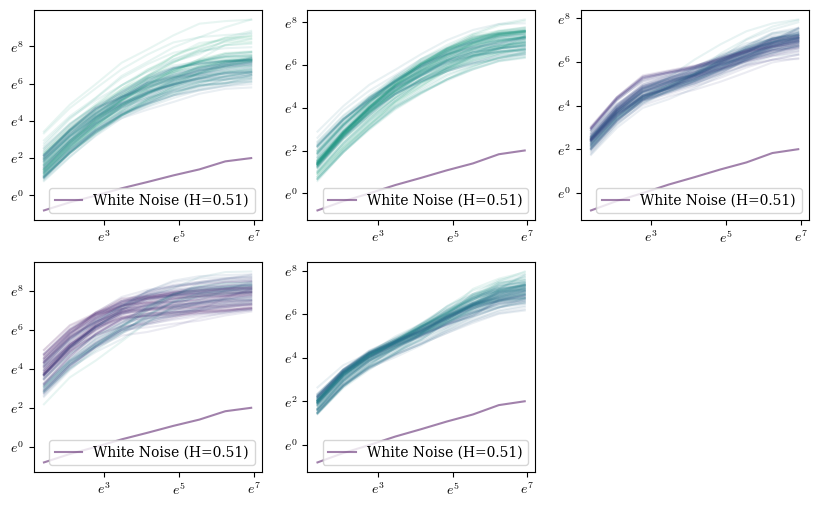

In [7]:
def exp_formatter(val, pos):
    p = np.log(val)            # since base e
    if np.isclose(p, round(p)):
        p = int(round(p))      # clean integer exponent
    return fr"$e^{p}$"

# Colormap and normalization
cmap = plt.cm.viridis
norm = plt.Normalize(0.5, 1.5)

fig, axs = plt.subplots(2,3,figsize=(10, 6))
for i in range(2):
    for j in range(3):
        if i == 1 and j == 2:
            axs[i,j].axis('off')
        else:
            for T in range(100):
                axs[i,j].plot(epochs, Data[i*3 + j][T], color=cmap(norm(Hurst[i*3 + j][T])), alpha=0.1)

            axs[i,j].plot(epochs, DFA_result_wn, color=cmap(norm(Hurst_wn)), alpha=0.5, label=f'White Noise (H={Hurst_wn:.2f})')
            axs[i,j].set_xscale('log', base=np.e)
            axs[i,j].set_yscale('log', base=np.e)
            axs[i,j].xaxis.set_major_formatter(ticker.FuncFormatter(exp_formatter))
            axs[i,j].yaxis.set_major_formatter(ticker.FuncFormatter(exp_formatter))
            axs[i,j].legend()

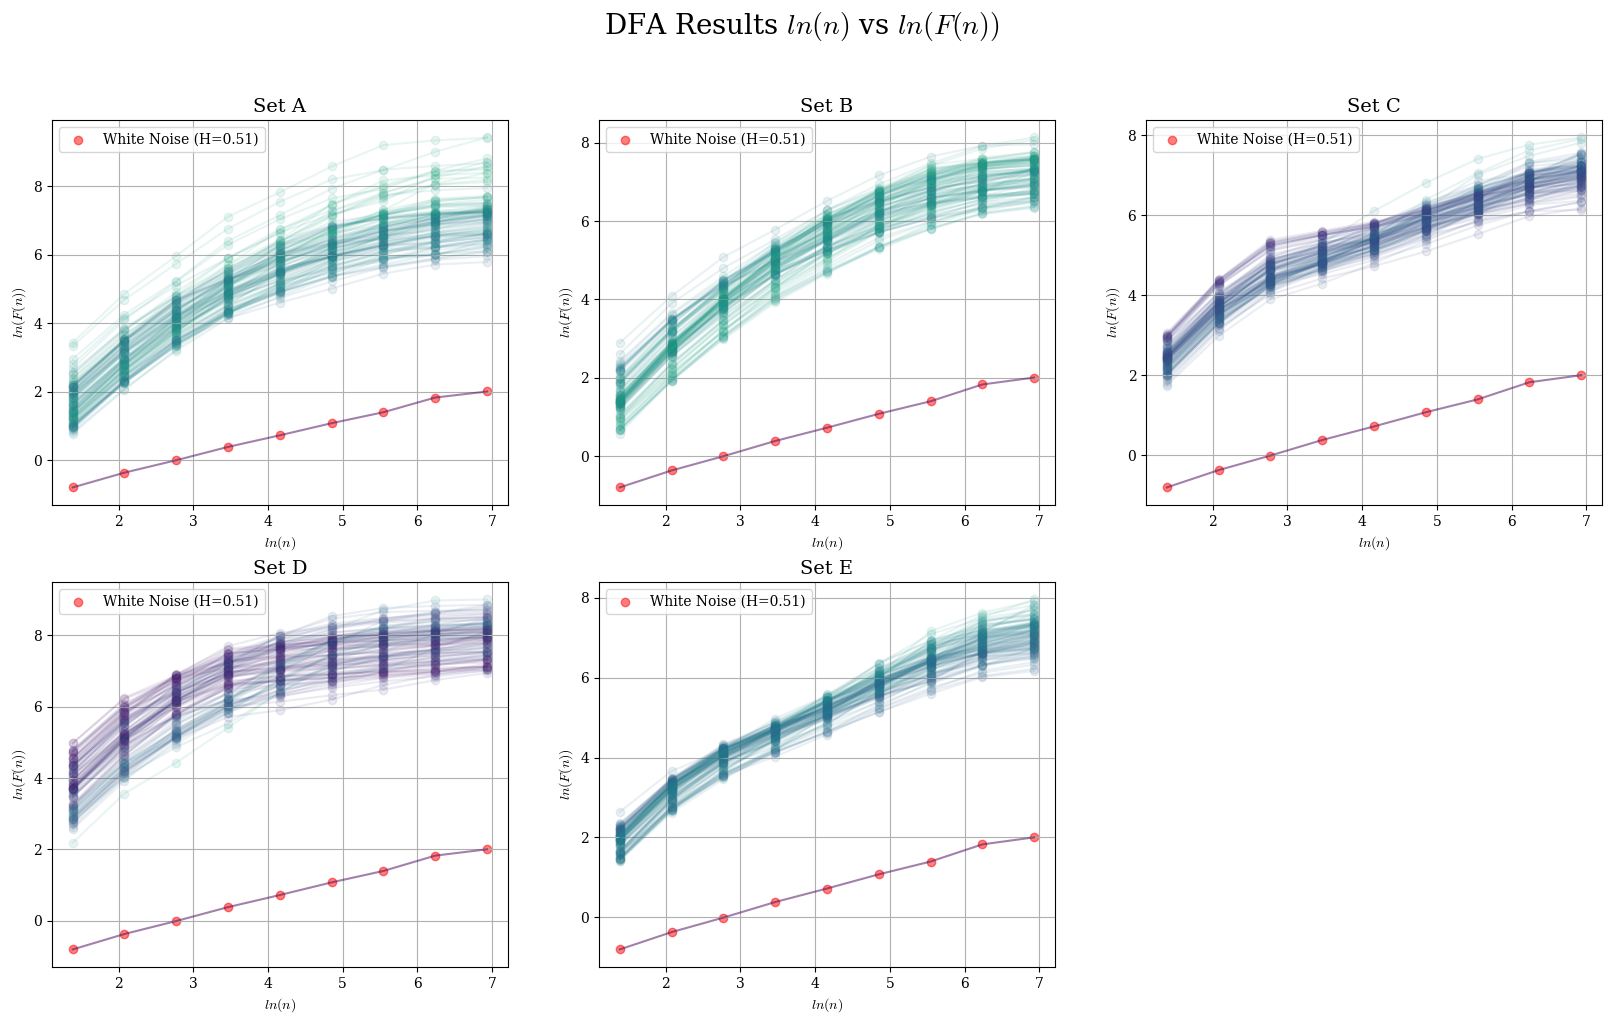

In [18]:
fig, axs = plt.subplots(2,3, figsize=(20,11))
plt.suptitle(f'DFA Results $ln(n)$ vs $ln(F(n))$', fontsize=20)
for i in range(2):
    for j in range(3):
        if i == 1 and j == 2:
            axs[i,j].axis('off')
        else:
            for T in range(100):
                axs[i,j].plot(np.log(epochs), np.log(Data[i*3 + j][T]), color=cmap(norm(Hurst[i*3 + j][T])), alpha=0.1)
                axs[i,j].scatter(np.log(epochs), np.log(Data[i*3 + j][T]), color=cmap(norm(Hurst[i*3 + j][T])), alpha=0.1)
                axs[i,j].set_title(f'Set {setnames[i*3 + j]}', fontsize=14)
                axs[i,j].set_xlabel(f'$ln(n)$')
                axs[i,j].set_ylabel(f'$ln(F(n))$')

            axs[i,j].plot(np.log(epochs), np.log(DFA_result_wn), color=cmap(norm(Hurst_wn)), alpha=0.5)
            axs[i,j].scatter(np.log(epochs), np.log(DFA_result_wn), color='red', alpha=0.5, label=f'White Noise (H={Hurst_wn:.2f})')
            # axs[i,j].set_xscale('log')
            # axs[i,j].set_yscale('log')
            axs[i,j].legend()
            axs[i,j].grid(True)

plt.savefig(f'DFA Results.png', dpi=200)

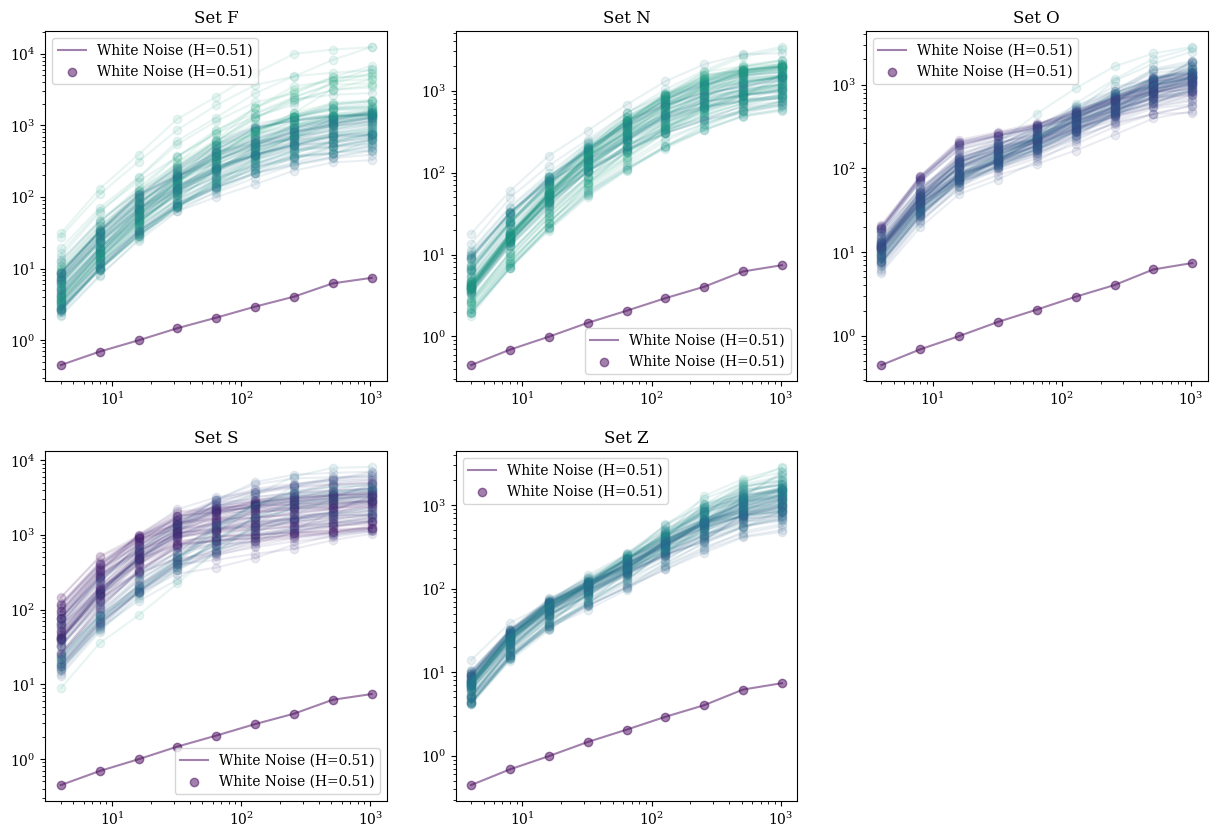

In [9]:
fig, axs = plt.subplots(2,3,figsize=(15, 10))
for i in range(2):
    for j in range(3):
        if i == 1 and j == 2:
            axs[i,j].axis('off')
        else:
            for T in range(100):
                axs[i,j].plot(epochs, Data[i*3 + j][T], color=cmap(norm(Hurst[i*3 + j][T])), alpha=0.1)
                axs[i,j].scatter(epochs, Data[i*3 + j][T], color=cmap(norm(Hurst[i*3 + j][T])), alpha=0.1)
                axs[i,j].set_title(f'Set {filenames[i*3 + j]}')
                


            axs[i,j].plot(epochs, DFA_result_wn, color=cmap(norm(Hurst_wn)), alpha=0.5, label=f'White Noise (H={Hurst_wn:.2f})')
            axs[i,j].scatter(epochs, DFA_result_wn, color=cmap(norm(Hurst_wn)), alpha=0.5, label=f'White Noise (H={Hurst_wn:.2f})')
            axs[i,j].set_xscale('log')
            axs[i,j].set_yscale('log')
            axs[i,j].legend()

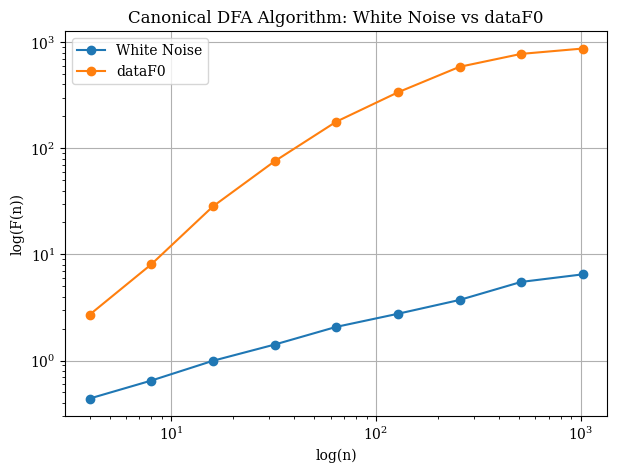

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# Helper functions
# -----------------------

def prepros(tseries):
    return np.cumsum(tseries - np.mean(tseries))

def DFA(data, epochs):
    F = []
    N = len(data)

    for n in epochs.astype(int):
        segments = N // n
        residuals = []

        for j in range(segments):
            seg = data[j*n:(j+1)*n]
            x = np.arange(n)

            # linear detrend
            coeff = np.polyfit(x, seg, 1)
            trend = np.polyval(coeff, x)

            residual = seg - trend              # residuals for this segment
            residuals.append(residual)          # collect residuals for all segments

        F.append(np.sqrt( np.mean (np.array(residuals)**2) ))

    return np.array(F)

# -----------------------
# Epoch definition
# -----------------------
scales = 9
epochs = np.logspace(
    np.log10(4),
    np.log10(4096/4),
    scales
)

# -----------------------
# Generate 1×4097 white noise
# -----------------------
np.random.seed(0)
white_noise = np.random.randn(4097)
white_proc = prepros(white_noise)

# -----------------------
# Try loading dataF0
# -----------------------
dataF0 = dataF[0]
dataF0_proc = prepros(dataF0)

# -----------------------
# Run DFA on both datasets
# -----------------------
F_white = DFA(white_proc, epochs)
F_dataF0 = DFA(dataF0_proc, epochs)

# -----------------------
# Plotting
# -----------------------
plt.figure(figsize=(7,5))
plt.loglog(epochs, F_white, 'o-', label='White Noise')
plt.loglog(epochs, F_dataF0, 'o-', label='dataF0')

plt.xlabel("log(n)")
plt.ylabel("log(F(n))")
plt.title("Canonical DFA Algorithm: White Noise vs dataF0")
plt.grid(True)
plt.legend()
plt.show()


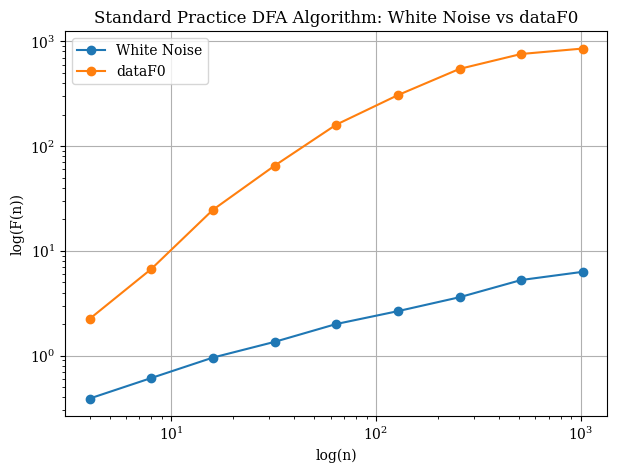

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# Helper functions
# -----------------------

def prepros(tseries):
    return np.cumsum(tseries - np.mean(tseries))

def DFA(data, epochs):
    F = []
    N = len(data)

    for n in epochs.astype(int):
        segments = N // n
        rms_list = []

        for j in range(segments):
            seg = data[j*n:(j+1)*n]
            x = np.arange(n)

            # linear detrend
            coeff = np.polyfit(x, seg, 1)
            trend = np.polyval(coeff, x)

            rms = np.sqrt(np.mean((seg - trend)**2))
            rms_list.append(rms)

        F.append(np.mean(rms_list))

    return np.array(F)

# -----------------------
# Epoch definition
# -----------------------
scales = 9
epochs = np.logspace(
    np.log10(4),
    np.log10(4096/4),
    scales
)

# -----------------------
# Generate 1×4097 white noise
# -----------------------
np.random.seed(0)
white_noise = np.random.randn(4097)
white_proc = prepros(white_noise)

# -----------------------
# Try loading dataF0
# -----------------------
dataF0 = dataF[0]
dataF0_proc = prepros(dataF0)

# -----------------------
# Run DFA on both datasets
# -----------------------
F_white = DFA(white_proc, epochs)
F_dataF0 = DFA(dataF0_proc, epochs)

# -----------------------
# Plotting
# -----------------------
plt.figure(figsize=(7,5))
plt.loglog(epochs, F_white, 'o-', label='White Noise')
plt.loglog(epochs, F_dataF0, 'o-', label='dataF0')

plt.xlabel("log(n)")
plt.ylabel("log(F(n))")
plt.title("Standard Practice DFA Algorithm: White Noise vs dataF0")
plt.grid(True)
plt.legend()
plt.show()


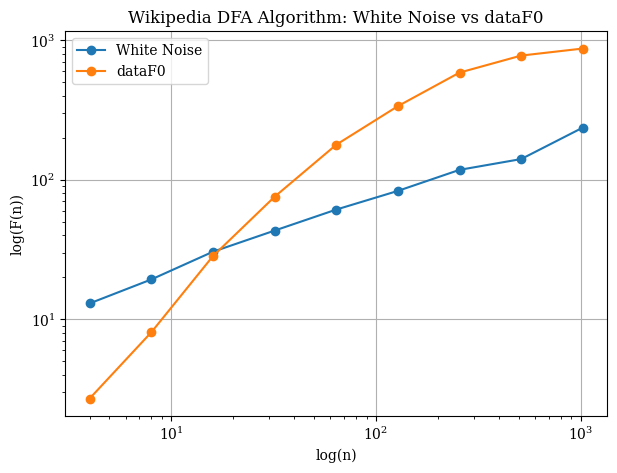

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# Helper functions
# -----------------------

def prepros(tseries):
    return np.cumsum(tseries - np.mean(tseries))

def DFA(data, epochs):
    F = []
    N = len(data)

    for n in epochs.astype(int):
        segments = N // n
        rms_list = []

        for j in range(segments):
            seg = data[j*n:(j+1)*n]
            x = np.arange(n)

            # linear detrend
            coeff = np.polyfit(x, seg, 1)
            trend = np.polyval(coeff, x)

            rms = np.sqrt(np.mean((seg - trend)**2))        # Segment Level
            rms_list.append(rms)

        F.append(np.sqrt(np.mean(np.array(rms_list)**2)))   # Timeseries Level

    return np.array(F)                                      # All epochs level

# -----------------------
# Epoch definition
# -----------------------
scales = 9
epochs = np.logspace(
    np.log10(4),
    np.log10(4096/4),
    scales
)

# -----------------------
# Generate 1×4097 white noise
# -----------------------
np.random.seed(0)
white_noise = np.random.uniform(0, 100, size=(1, 4097))[0]
white_proc = prepros(white_noise)

# -----------------------
# Try loading dataF0
# -----------------------
dataF0 = dataF[0]
dataF0_proc = prepros(dataF0)

# -----------------------
# Run DFA on both datasets
# -----------------------
F_white = DFA(white_proc, epochs)
F_dataF0 = DFA(dataF0_proc, epochs)

# -----------------------
# Plotting
# -----------------------
plt.figure(figsize=(7,5))
plt.loglog(epochs, F_white, 'o-', label='White Noise')
plt.loglog(epochs, F_dataF0, 'o-', label='dataF0')

plt.xlabel("log(n)")
plt.ylabel("log(F(n))")
plt.title("Wikipedia DFA Algorithm: White Noise vs dataF0")
plt.grid(True)
plt.legend()
plt.show()


In [13]:
a = np.random.uniform(-100, 100, size=(1, 4097))[0]
print(len(a))

4097
